 EDA project

#### CROMA STORE DATA

#### 1) Understanding problem / statement


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers=pd.read_csv('messy_customers.csv')
order_item=pd.read_csv('messy_order_items.csv')
orders=pd.read_csv('messy_orders.csv')
products=pd.read_csv('messy_products.csv')

In [3]:
customers

,customer_id,customer_name,city,signup_date
0,C0001,Customer_1,DELHI,2024-02-09
1,C0002,Customer_2,delhi,2025-04-20
2,C0003,Customer_3,Bangalore,2024-08-19
3,C0004,Customer_4,Pune,2023-08-08
4,C0005,NaN,Bengaluru,2024-03-04
...,...,...,...,...
515,C0391,Customer_391,Kolkata,2023-01-07
516,C0483,Customer_483,Delhi,2023-02-25
517,C0473,Customer_473,Bangalore,2023-12-05
518,C0417,Customer_417,Bangalore,2025-01-24


i have data of 520 customers with having unique ID , name , city and their signup date

In [4]:
customers[customers.duplicated(keep=False)]

,customer_id,customer_name,city,signup_date
13,C0014,Customer_14,delhi,2024-08-18
32,C0033,Customer_33,mumbai,2024-04-30
132,C0133,Customer_133,Mumbai,2025-05-10
155,C0156,Customer_156,Pune,2024-08-07
179,C0180,Customer_180,NaN,2025-01-16
217,C0218,Customer_218,delhi,2025-02-02
221,C0222,Customer_222,Hyderabad,2024-05-20
249,C0250,Customer_250,Mumbai,2024-12-31
293,C0294,Customer_294,Hyderabad,2023-09-12
302,C0303,Customer_303,Kolkata,2024-03-23


customers table also have some duplicate values in my data so  i have to delete it in order to make analysis process better

In [5]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customer_id    520 non-null    str  
 1   customer_name  492 non-null    str  
 2   city           479 non-null    str  
 3   signup_date    520 non-null    str  
dtypes: str(4)
memory usage: 16.4 KB


i have a column as 3   signup_date    520 non-null    str  which is not in proper format so i hvae to conver it into pandas date time format
also in column customer name and city i have 

In [6]:
customers.describe()

,customer_id,customer_name,city,signup_date
count,520,492,479,520
unique,500,472,11,379
top,C0014,Customer_14,Hyderabad,2023-06-15
freq,2,2,54,4


In [7]:
order_item

,order_item_id,order_id,product_id,quantity,unit_price
0,1,O00380,P033,2.0,NaN
1,2,O00857,P010,1.0,NaN
2,3,O00589,P007,2.0,77415.0
3,4,O00112,P045,2.0,49066.0
4,5,O00322,P036,2.0,58380.0
...,...,...,...,...,...
2045,1166,O00667,P034,3.0,47907.0
2046,841,O00120,P050,4.0,41680.0
2047,399,O00053,P055,NaN,NaN
2048,545,O01182,P005,3.0,NaN


In [8]:
order_item[order_item.duplicated(keep=False)]

,order_item_id,order_id,product_id,quantity,unit_price
110,111,O01090,P018,0.0,41057.0
155,156,O00621,P020,1.0,NaN
158,159,O00727,P002,1.0,34931.0
196,197,O00301,P003,3.0,60818.0
275,276,O00571,P022,1.0,20373.0
...,...,...,...,...,...
2045,1166,O00667,P034,3.0,47907.0
2046,841,O00120,P050,4.0,41680.0
2047,399,O00053,P055,NaN,NaN
2048,545,O01182,P005,3.0,NaN


In [9]:
order_item.info()

<class 'pandas.DataFrame'>
RangeIndex: 2050 entries, 0 to 2049
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_item_id  2050 non-null   int64  
 1   order_id       2050 non-null   str    
 2   product_id     2050 non-null   str    
 3   quantity       1732 non-null   float64
 4   unit_price     1039 non-null   float64
dtypes: float64(2), int64(1), str(2)
memory usage: 80.2 KB


In [10]:
order_item.describe()

,order_item_id,quantity,unit_price
count,2050.000000,1732.000000,1039.000000
mean,999.866341,1.991339,44956.006737
std,576.435038,1.411120,24978.977806
min,1.000000,0.000000,1072.000000
25%,502.250000,1.000000,23987.000000
50%,998.500000,2.000000,43654.000000
75%,1499.750000,3.000000,65136.500000
max,2000.000000,4.000000,89980.000000


In [11]:
orders

,order_id,customer_id,order_date,payment_method
0,O00001,C0058,09/05/2024,Cash on Delivery
1,O00002,C0410,2024-02-01,upi
2,O00003,C0429,13/04/2025,Cash
3,O00004,C0272,2024-02-25,Debit Card
4,O00005,C0411,04-26-2025,credit card
...,...,...,...,...
1235,O01078,C0222,03-15-2025,Cash on Delivery
1236,O00944,C0014,04-08-2024,credit card
1237,O00128,C0383,03-31-2025,Credit Card
1238,O00966,C0053,23/02/2024,upi


In [12]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 1240 entries, 0 to 1239
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   order_id        1240 non-null   str  
 1   customer_id     1240 non-null   str  
 2   order_date      1240 non-null   str  
 3   payment_method  1095 non-null   str  
dtypes: str(4)
memory usage: 38.9 KB


In [13]:
orders[orders.duplicated(keep=False)]

,order_id,customer_id,order_date,payment_method
14,O00015,C0329,02/09/2024,Cash on Delivery
71,O00072,C0033,2024-01-06,UPI
116,O00117,C0061,04-07-2025,UPI
127,O00128,C0383,03-31-2025,Credit Card
140,O00141,C0217,13/10/2024,Debit Card
...,...,...,...,...
1235,O01078,C0222,03-15-2025,Cash on Delivery
1236,O00944,C0014,04-08-2024,credit card
1237,O00128,C0383,03-31-2025,Credit Card
1238,O00966,C0053,23/02/2024,upi


In [14]:
products

,product_id,product_name,category,base_price
0,P001,Lenovo IdeaPad,Tablet,28151.0
1,P002,Samsung Tab,Smartphone,68660.0
2,P003,HP Pavilion,Accessories,NaN
3,P004,Lenovo Tab,tablet,NaN
4,P005,OnePlus,Tablet,NaN
...,...,...,...,...
85,P022,Samsung Tab,Accessory,NaN
86,P052,Xiaomi Redmi,smart phone,NaN
87,P010,iPhone 13,smart phone,NaN
88,P059,OnePlus,Accessories,NaN


In [15]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    90 non-null     str    
 1   product_name  90 non-null     str    
 2   category      90 non-null     str    
 3   base_price    33 non-null     float64
dtypes: float64(1), str(3)
memory usage: 2.9 KB


In [16]:
products.describe()

,base_price
count,33.000000
mean,45047.454545
std,25654.215131
min,2571.000000
25%,27157.000000
50%,47453.000000
75%,68660.000000
max,84776.000000


In [17]:
products[products.duplicated(keep=False)]

,product_id,product_name,category,base_price
9,P010,iPhone 13,smart phone,NaN
16,P017,Keyboard,Smartphone,NaN
19,P020,Dell Inspiron,Smartphone,NaN
21,P022,Samsung Tab,Accessory,NaN
32,P033,Wireless Mouse,laptop,47453.0
51,P052,Xiaomi Redmi,smart phone,NaN
58,P059,OnePlus,Accessories,NaN
61,P062,Dell Inspiron,Tablet,NaN
71,P072,Dell Inspiron,Tablet,NaN
75,P076,Wireless Mouse,Accessory,15249.0


#### 2) Pre-processing data

In [18]:
customers.drop_duplicates(inplace=True)

In [19]:
order_item.drop_duplicates(inplace=True)

In [20]:
orders.drop_duplicates(inplace=True)

In [21]:
products.drop_duplicates(inplace=True)

In [22]:
customers['signup_date'] = pd.to_datetime(customers['signup_date'])

In [23]:
orders['order_date'] = pd.to_datetime(orders['order_date'],format='mixed')

#### 3) Handling Inconsistant Data

In [24]:
customers['city'] = customers['city'].str.title()

In [25]:
customers['city'] = customers['city'].replace({'Bangalore':'Bengaluru'}).copy()

In [26]:
products['category'] = products['category'].str.title()
products['category'] = products['category'].replace({"Accessory":"Accessories","Smart Phone":"Smartphone"})

In [27]:
orders['payment_method'] = orders['payment_method'].str.title()
orders['payment_method']= orders['payment_method'].replace({"Cash On Delivery":"Cash"})

#### 4) Handling missing values

In [35]:
customers.isnull().sum()

customer_id       0
customer_name    28
city              0
signup_date       0
dtype: int64

In [36]:
orders.isnull().sum()

order_id          0
customer_id       0
order_date        0
payment_method    0
dtype: int64

In [37]:
order_item.isnull().sum()

order_item_id      0
order_id           0
product_id         0
quantity         313
unit_price       990
dtype: int64

In [38]:
products.isnull().sum()

product_id       0
product_name     0
category         0
base_price      49
dtype: int64

In [32]:
orders['payment_method'] = orders['payment_method'].ffill().copy()

In [33]:
customers['city'] = customers['city'].bfill().copy()

In [48]:
order_item['unit_price'] = order_item['unit_price'].fillna(order_item['product_id'].map(products.set_index('product_id')['base_price']))

In [50]:
order_item.isnull().sum()

order_item_id      0
order_id           0
product_id         0
quantity         313
unit_price       604
dtype: int64

In [55]:
order_item.fillna({'quantity':order_item['quantity'].mean(),'unit_price':order_item['unit_price'].mean()},inplace=True)

,order_item_id,order_id,product_id,quantity,unit_price
0,1,O00380,P033,2.000000,47453.000000
1,2,O00857,P010,1.000000,45038.245702
2,3,O00589,P007,2.000000,77415.000000
3,4,O00112,P045,2.000000,49066.000000
4,5,O00322,P036,2.000000,58380.000000
...,...,...,...,...,...
1995,1996,O00944,P007,4.000000,64106.000000
1996,1997,O00629,P017,4.000000,45038.245702
1997,1998,O00703,P008,0.000000,76524.000000
1998,1999,O01083,P043,3.000000,18251.000000


In [56]:
order_item.isnull().sum()

order_item_id    0
order_id         0
product_id       0
quantity         0
unit_price       0
dtype: int64

In [58]:
order_item['quantity'] = order_item['quantity'].astype('int')

In [59]:
products

,product_id,product_name,category,base_price
0,P001,Lenovo IdeaPad,Tablet,28151.0
1,P002,Samsung Tab,Smartphone,68660.0
2,P003,HP Pavilion,Accessories,NaN
3,P004,Lenovo Tab,Tablet,NaN
4,P005,OnePlus,Tablet,NaN
...,...,...,...,...
75,P076,Wireless Mouse,Accessories,15249.0
76,P077,Wireless Mouse,Smartphone,NaN
77,P078,USB Hub,Accessories,70378.0
78,P079,OnePlus,Tablet,NaN


#### 5) Merging Data

In [60]:
first = order_item.merge(products,on='product_id',how='outer')

In [64]:
second = orders.merge(customers,on='customer_id',how='outer')

In [71]:
df = first.merge(second,on='order_id',how='inner')

In [72]:
df

,order_item_id,order_id,product_id,quantity,unit_price,product_name,category,base_price,customer_id,order_date,payment_method,customer_name,city,signup_date
0,228,O00862,P001,1,30940.0,Lenovo IdeaPad,Tablet,28151.0,C0246,2024-09-24,Cash,Customer_246,Mumbai,2025-01-14
1,427,O00610,P001,4,28151.0,Lenovo IdeaPad,Tablet,28151.0,C0233,2024-10-23,Upi,Customer_233,Hyderabad,2025-02-24
2,618,O00343,P001,4,28151.0,Lenovo IdeaPad,Tablet,28151.0,C0009,2024-07-02,Debit Card,Customer_9,Delhi,2024-08-13
3,634,O00485,P001,1,28151.0,Lenovo IdeaPad,Tablet,28151.0,C0370,2024-01-24,Credit Card,Customer_370,Mumbai,2023-04-09
4,662,O01127,P001,1,34936.0,Lenovo IdeaPad,Tablet,28151.0,C0168,2025-04-09,Credit Card,Customer_168,Delhi,2023-07-26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1662,O01122,P080,1,82478.0,OnePlus,Laptop,82478.0,C0084,2025-03-11,Credit Card,Customer_84,Mumbai,2023-01-30
1996,1695,O00412,P080,2,82478.0,OnePlus,Laptop,82478.0,C0217,2024-03-27,Upi,Customer_217,Pune,2023-04-05
1997,1814,O00575,P080,0,80491.0,OnePlus,Laptop,82478.0,C0213,2024-10-01,Cash,Customer_213,Pune,2023-02-21
1998,1872,O00288,P080,2,82478.0,OnePlus,Laptop,82478.0,C0253,2024-07-25,Credit Card,Customer_253,Chennai,2023-03-20


#### 6) Transform Data / Feature Engineering

In [73]:
df['Amount'] = df['quantity']*df['unit_price']

In [75]:
df['year'] = df['order_date'].dt.year

In [88]:
df['month'] = df['order_date'].dt.month_name()

In [89]:
df

,order_item_id,order_id,product_id,quantity,unit_price,product_name,category,base_price,customer_id,order_date,payment_method,customer_name,city,signup_date,Amount,year,month
0,228,O00862,P001,1,30940.0,Lenovo IdeaPad,Tablet,28151.0,C0246,2024-09-24,Cash,Customer_246,Mumbai,2025-01-14,30940.0,2024,September
1,427,O00610,P001,4,28151.0,Lenovo IdeaPad,Tablet,28151.0,C0233,2024-10-23,Upi,Customer_233,Hyderabad,2025-02-24,112604.0,2024,October
2,618,O00343,P001,4,28151.0,Lenovo IdeaPad,Tablet,28151.0,C0009,2024-07-02,Debit Card,Customer_9,Delhi,2024-08-13,112604.0,2024,July
3,634,O00485,P001,1,28151.0,Lenovo IdeaPad,Tablet,28151.0,C0370,2024-01-24,Credit Card,Customer_370,Mumbai,2023-04-09,28151.0,2024,January
4,662,O01127,P001,1,34936.0,Lenovo IdeaPad,Tablet,28151.0,C0168,2025-04-09,Credit Card,Customer_168,Delhi,2023-07-26,34936.0,2025,April
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1662,O01122,P080,1,82478.0,OnePlus,Laptop,82478.0,C0084,2025-03-11,Credit Card,Customer_84,Mumbai,2023-01-30,82478.0,2025,March
1996,1695,O00412,P080,2,82478.0,OnePlus,Laptop,82478.0,C0217,2024-03-27,Upi,Customer_217,Pune,2023-04-05,164956.0,2024,March
1997,1814,O00575,P080,0,80491.0,OnePlus,Laptop,82478.0,C0213,2024-10-01,Cash,Customer_213,Pune,2023-02-21,0.0,2024,October
1998,1872,O00288,P080,2,82478.0,OnePlus,Laptop,82478.0,C0253,2024-07-25,Credit Card,Customer_253,Chennai,2023-03-20,164956.0,2024,July


#### 7) Exploring Data & Visualization

In [93]:
#total revenue
total_revenue = df['Amount'].sum()
print(total_revenue.astype(int))

165023180


In [100]:
# revenue by month
monthly_sales = df.groupby('month')['Amount'].sum().astype('int')
print(monthly_sales.sort_values(ascending=False))

month
January      22296015
April        21569575
March        20284421
February     17330222
May          14990969
June         11699719
December     10593763
July          9962422
October       9663569
November      9550624
September     8952460
August        8129417
Name: Amount, dtype: int64


Text(0, 0.5, 'REVENUE')

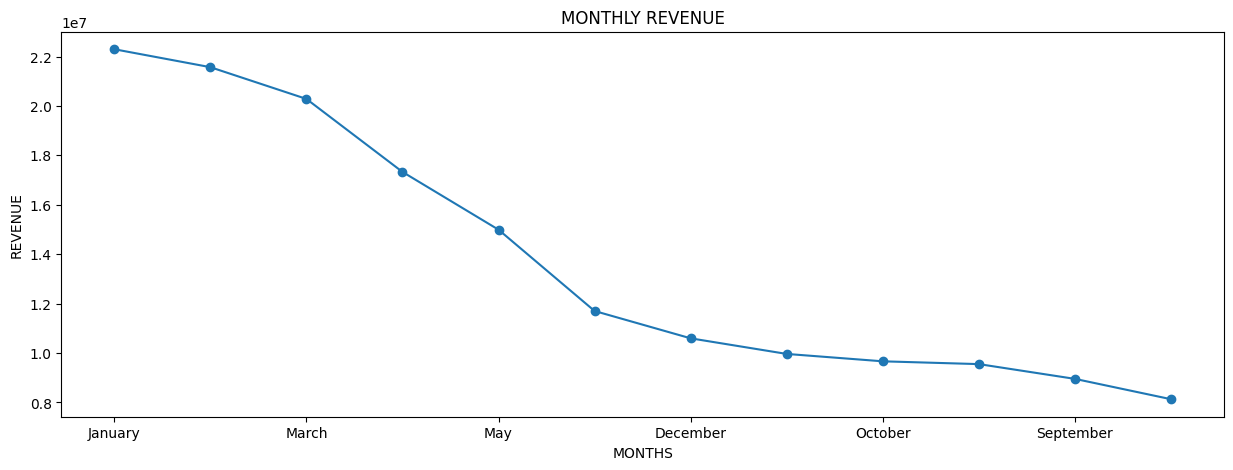

In [103]:
# monthly revenue
plt.figure(figsize=(15,5))
monthly_sales.sort_values(ascending=False).plot(kind='line',marker='o')
plt.title('MONTHLY REVENUE')
plt.xlabel('MONTHS')
plt.ylabel('REVENUE')

january month has highest sales

In [116]:
# top_product_by revenue
top_product=df.groupby('product_name')['Amount'].sum().head(5).astype('int')
top_5_prod = pd.DataFrame(top_product.sort_values(ascending=False))
top_5_prod

,Amount
product_name,
Dell Inspiron,17443441
Laptop Bag,17389637
Lenovo IdeaPad,11479789
Keyboard,8818222
HP Pavilion,6206948


Text(0, 0.5, 'REVENUE')

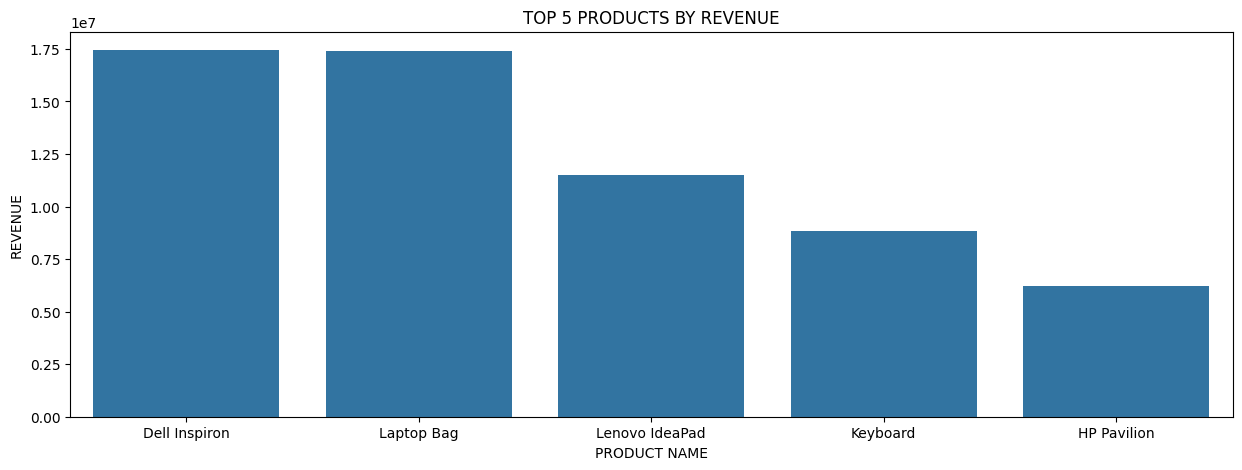

In [115]:
plt.figure(figsize=(15,5))
sns.barplot(x='product_name',y='Amount',data=top_5_prod)
plt.title('TOP 5 PRODUCTS BY REVENUE')
plt.xlabel('PRODUCT NAME')
plt.ylabel('REVENUE')

In [118]:
top_customer=df.groupby('customer_id')['Amount'].sum().head(5)
top_5_cust = pd.DataFrame(top_customer.sort_values(ascending=False))
top_5_cust

,Amount
customer_id,
C0001,1.089959e+06
C0005,8.904162e+05
C0003,5.452300e+05
C0002,4.940862e+05
C0004,6.099600e+04


Text(0, 0.5, 'REVENUE')

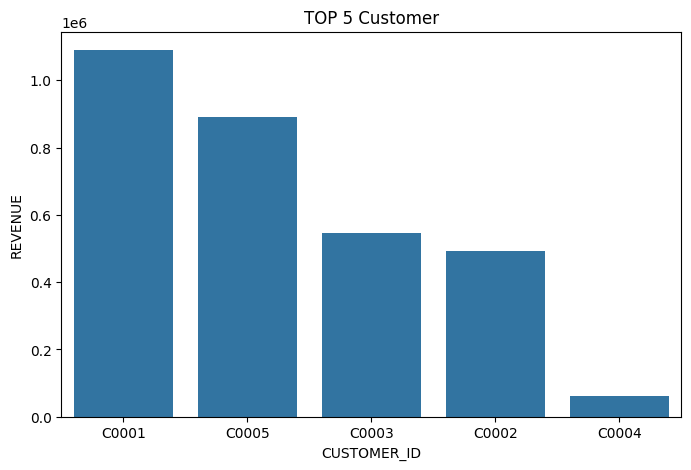

In [119]:
plt.figure(figsize=(8,5))
sns.barplot(x='customer_id',y='Amount',data=top_5_cust)
plt.title('TOP 5 Customer')
plt.xlabel('CUSTOMER_ID')
plt.ylabel('REVENUE')

Text(0.5, 1.0, 'Correlation')

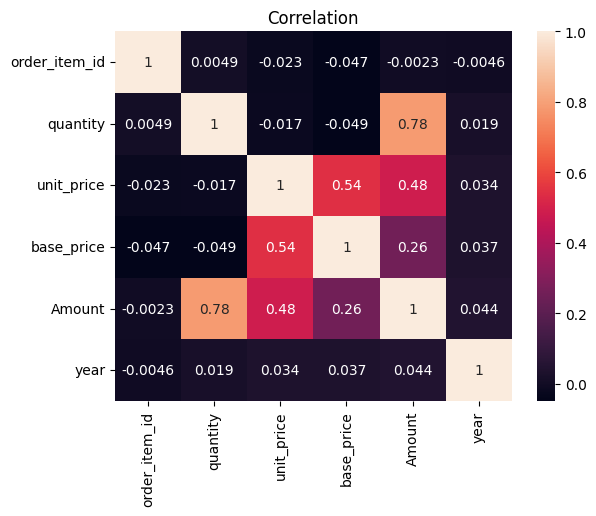

In [122]:
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(),annot=True)
plt.title('Correlation')

In [123]:
numeric_df.corr()

,order_item_id,quantity,unit_price,base_price,Amount,year
order_item_id,1.000000,0.004933,-0.023108,-0.047324,-0.002335,-0.004578
quantity,0.004933,1.000000,-0.016821,-0.048962,0.784052,0.018690
unit_price,-0.023108,-0.016821,1.000000,0.542167,0.483782,0.033557
base_price,-0.047324,-0.048962,0.542167,1.000000,0.255987,0.036631
Amount,-0.002335,0.784052,0.483782,0.255987,1.000000,0.043949
year,-0.004578,0.018690,0.033557,0.036631,0.043949,1.000000


#### 8) Final insights

In [ ]:
# In the Croma sales analysis data remove the duplicate values,apply merge and visualization in this data and the below results.

In [ ]:
# Total revenue = 165023180

In [ ]:
# The highest sales is january months (22296015)

In [ ]:
# Top sales product is Dell Inspiron (17443441)

In [ ]:
# Customer_id C0001 is top position in this charts